# Task 2 — Exploratory Data Analysis

**Objective:** analyze patterns and factors influencing financial inclusion in Ethiopia using the
enriched dataset from Task 1 (`data/processed/`).

Sections: 1) dataset overview & quality · 2) Access analysis · 3) Usage analysis ·
4) infrastructure & enablers · 5) event timeline & overlays · 6) correlations ·
7) key insights & data quality assessment.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# Validated palette (dataviz reference instance) — fixed slot order, never cycled
C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"  # blue, green, magenta, yellow
INK, INK2 = "#0b0b0b", "#52514e"
SEQ_BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("bwr_ref", ["#1c5cab", "#f0efec", "#d03b3b"])

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e4", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
})

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=150)

main = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv",
                   parse_dates=["observation_date"])
impact = pd.read_csv("../data/processed/impact_links_enriched.csv",
                     parse_dates=["observation_date"])
obs = main[main.record_type == "observation"].copy()
events = main[main.record_type == "event"].copy()
targets = main[main.record_type == "target"].copy()
obs["year"] = obs.observation_date.dt.year
print(f"{len(obs)} observations, {len(events)} events, {len(impact)} impact links, {len(targets)} targets")

43 observations, 12 events, 23 impact links, 3 targets


## 1. Dataset overview

In [2]:
display(pd.crosstab(main.record_type, main.pillar.fillna("(none)")))
display(pd.crosstab(main.source_type.fillna("(none)"), main.confidence.fillna("(none)")))

pillar,(none),ACCESS,AFFORDABILITY,GENDER,USAGE
record_type,,,,,
event,12,0,0,0,0
observation,0,19,1,4,19
target,0,2,0,1,0


confidence,estimated,high,medium
source_type,,,
calculated,2,2,0
news,0,2,1
operator,0,17,2
policy,0,2,1
regulator,0,8,0
research,0,3,1
survey,0,10,7


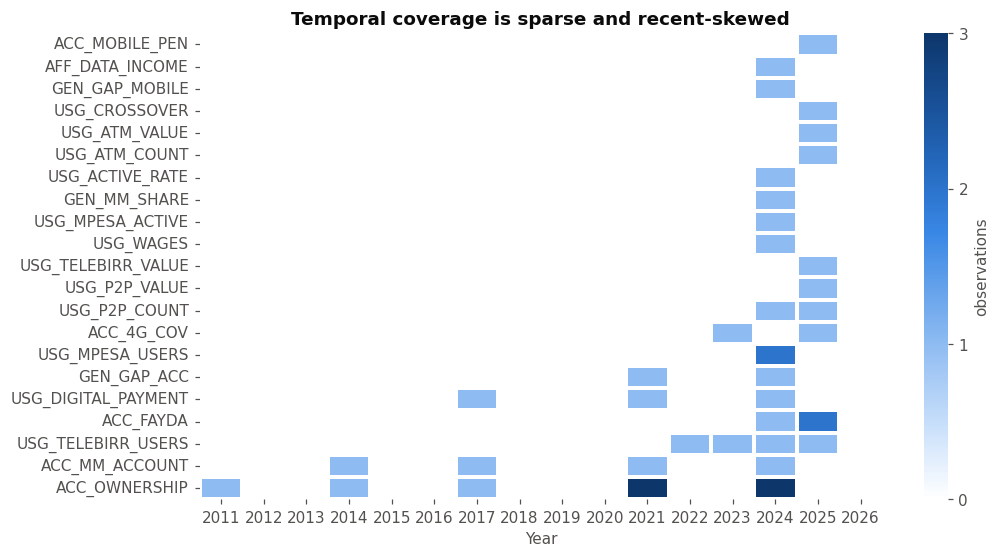

In [3]:
# Temporal coverage matrix: which years have data for which indicators?
cov = (obs.groupby(["indicator_code", "year"]).size().unstack(fill_value=0)
          .reindex(columns=range(2011, 2027), fill_value=0))
order = cov.sum(axis=1).sort_values().index
cov = cov.loc[order]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(cov, ax=ax, cmap=LinearSegmentedColormap.from_list("seq", ["#ffffff"] + SEQ_BLUES),
            vmin=0, vmax=3, cbar_kws={"label": "observations", "ticks": [0, 1, 2, 3]},
            linewidths=1.5, linecolor="white")
ax.set_title("Temporal coverage is sparse and recent-skewed")
ax.set_xlabel("Year"); ax.set_ylabel("")
ax.grid(False)
save(fig, "coverage_matrix.png"); plt.show()

**Reading:** survey indicators (`ACC_OWNERSHIP`, `USG_DIGITAL_PAYMENT`) have long but
3-yearly coverage; operator/infrastructure indicators are dense but only exist from ~2022.
No indicator has both depth and frequency — the core data limitation of this project.

**Confidence distribution:** most records are `high` (official surveys and operator reports);
`medium` marks secondary-sourced or press-reported figures, and the two `estimated` rows are the
derived 2024 gender split from Task 1.

## 2. Access — account ownership

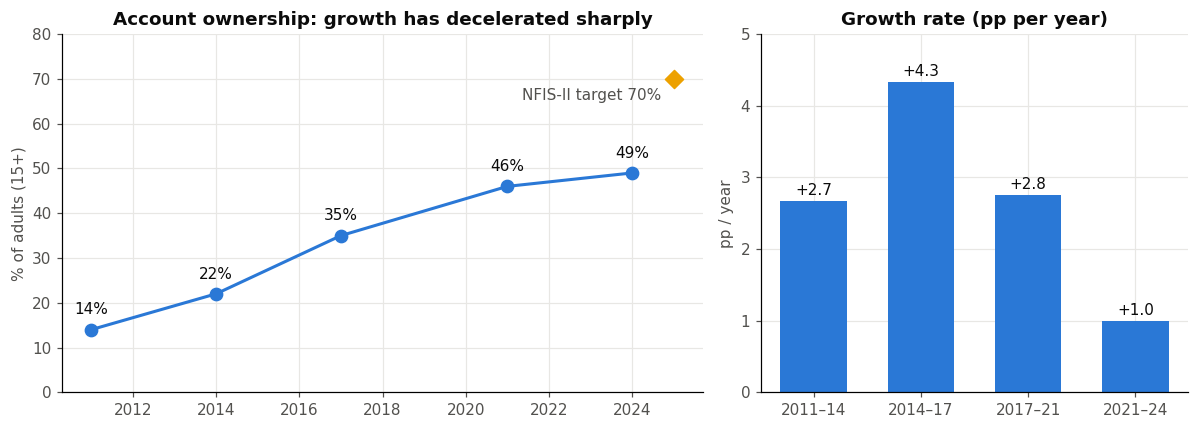

In [4]:
acc = obs[(obs.indicator_code == "ACC_OWNERSHIP") & (obs.gender == "all")].sort_values("year")
tgt = targets[targets.indicator_code == "ACC_OWNERSHIP"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 2]})
ax = axes[0]
ax.plot(acc.year, acc.value_numeric, color=C1, lw=2, marker="o", ms=8, zorder=3)
for _, r in acc.iterrows():
    ax.annotate(f"{r.value_numeric:.0f}%", (r.year, r.value_numeric),
                textcoords="offset points", xytext=(0, 10), ha="center", color=INK)
ax.scatter([2025], tgt.value_numeric, marker="D", s=70, color=C4, zorder=3)
ax.annotate("NFIS-II target 70%", (2025, float(tgt.value_numeric.iloc[0])),
            textcoords="offset points", xytext=(-8, -14), ha="right", color=INK2)
ax.set_title("Account ownership: growth has decelerated sharply")
ax.set_ylabel("% of adults (15+)"); ax.set_ylim(0, 80)

ax = axes[1]
periods = ["2011–14", "2014–17", "2017–21", "2021–24"]
vals = acc.value_numeric.to_numpy()
yrs = acc.year.to_numpy()
rates = np.diff(vals) / np.diff(yrs)
bars = ax.bar(periods, rates, color=C1, width=0.62)
for b, r in zip(bars, rates):
    ax.annotate(f"+{r:.1f}", (b.get_x() + b.get_width()/2, r),
                textcoords="offset points", xytext=(0, 4), ha="center", color=INK)
ax.set_title("Growth rate (pp per year)")
ax.set_ylabel("pp / year"); ax.set_ylim(0, 5)
fig.tight_layout()
save(fig, "access_trajectory.png"); plt.show()

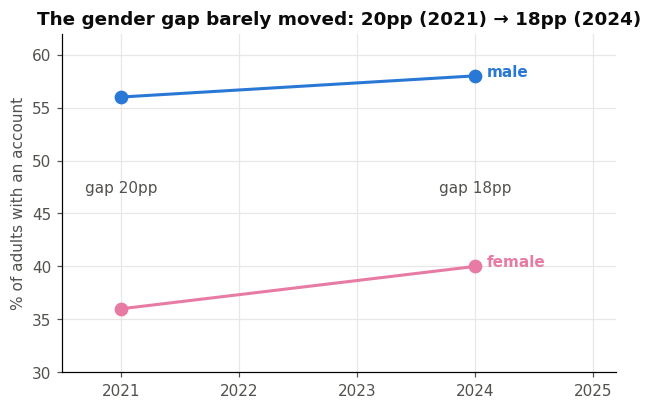

2024 male/female values are DERIVED from the overall rate + reported gap (confidence: estimated)


In [5]:
# Gender gap
g = obs[(obs.indicator_code == "ACC_OWNERSHIP") & (obs.gender != "all")]
gap = obs[obs.indicator_code == "GEN_GAP_ACC"].sort_values("year")

fig, ax = plt.subplots(figsize=(6.5, 4))
for gender, color in [("male", C1), ("female", C3)]:
    d = g[g.gender == gender].sort_values("year")
    ax.plot(d.year, d.value_numeric, color=color, lw=2, marker="o", ms=8)
    ax.annotate(gender, (d.year.iloc[-1], d.value_numeric.iloc[-1]),
                textcoords="offset points", xytext=(8, 0), color=color, fontweight="bold")
for _, r in gap.iterrows():
    ax.annotate(f"gap {r.value_numeric:.0f}pp", (r.year, 47), ha="center", color=INK2)
ax.set_title("The gender gap barely moved: 20pp (2021) → 18pp (2024)")
ax.set_ylabel("% of adults with an account"); ax.set_xlim(2020.5, 2025.2); ax.set_ylim(30, 62)
save(fig, "gender_gap.png"); plt.show()
print("2024 male/female values are DERIVED from the overall rate + reported gap (confidence: estimated)")

**The 2021–2024 slowdown.** Ownership grew just +1.0pp/yr (vs +2.7 to +4.3 in prior periods)
even though 65M+ mobile money wallets were registered. Candidate explanations examined below:
(1) wallet registration is not Findex "account ownership" — many wallets belong to adults who
already had bank accounts (Sheet D: mobile-money-*only* users are ~0.5% of adults);
(2) duplicate/inactive registrations inflate operator counts (M-Pesa's own 90-day active rate is 66%);
(3) the binding constraints — gender gap, rural connectivity, ID, affordability — persisted through
the expansion; (4) macro instability (conflict, FX crisis, inflation) suppressed formal saving.

## 3. Usage — mobile money and digital payments

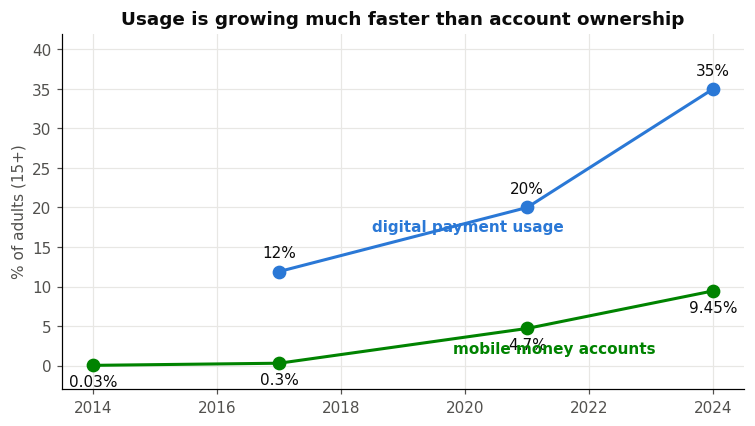

In [6]:
mm = obs[obs.indicator_code == "ACC_MM_ACCOUNT"].sort_values("year")
dp = obs[obs.indicator_code == "USG_DIGITAL_PAYMENT"].sort_values("year")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(dp.year, dp.value_numeric, color=C1, lw=2, marker="o", ms=8)
ax.plot(mm.year, mm.value_numeric, color=C2, lw=2, marker="o", ms=8)
for _, r in dp.iterrows():
    ax.annotate(f"{r.value_numeric:.0f}%", (r.year, r.value_numeric),
                textcoords="offset points", xytext=(0, 9), ha="center", color=INK)
for _, r in mm.iterrows():
    ax.annotate(f"{r.value_numeric:g}%", (r.year, r.value_numeric),
                textcoords="offset points", xytext=(0, -14), ha="center", color=INK)
ax.annotate("digital payment usage", (2018.5, 17), color=C1, fontweight="bold")
ax.annotate("mobile money accounts", (2019.8, 1.5), color=C2, fontweight="bold")
ax.set_title("Usage is growing much faster than account ownership")
ax.set_ylabel("% of adults (15+)"); ax.set_ylim(-3, 42)
save(fig, "usage_trends.png"); plt.show()

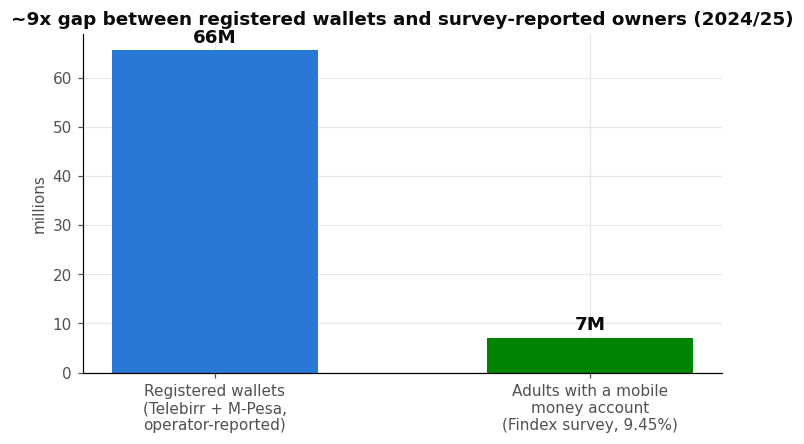

Registered: 66M wallets vs ~7M survey-reported owners (adult population assumed ~75M)


In [7]:
# Registered vs survey-reported: the activity gap
ADULT_POP = 75e6  # Ethiopia adults 15+, rough estimate (pop ~130M, ~57% adult) — for scale only
telebirr = obs[obs.indicator_code == "USG_TELEBIRR_USERS"].sort_values("observation_date")
mpesa_reg = float(obs.loc[obs.indicator_code == "USG_MPESA_USERS", "value_numeric"].max())
mm_2024 = 9.45 / 100 * ADULT_POP

fig, ax = plt.subplots(figsize=(7.5, 4))
labels = ["Registered wallets\n(Telebirr + M-Pesa,\noperator-reported)",
          "Adults with a mobile\nmoney account\n(Findex survey, 9.45%)"]
vals = [(telebirr.value_numeric.iloc[-1] + mpesa_reg) / 1e6, mm_2024 / 1e6]
bars = ax.bar(labels, vals, color=[C1, C2], width=0.55)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.0f}M", (b.get_x() + b.get_width()/2, v),
                textcoords="offset points", xytext=(0, 5), ha="center",
                color=INK, fontweight="bold", fontsize=12)
ax.set_title("~9x gap between registered wallets and survey-reported owners (2024/25)")
ax.set_ylabel("millions")
save(fig, "registered_vs_survey.png"); plt.show()
print(f"Registered: {vals[0]:.0f}M wallets vs ~{vals[1]:.0f}M survey-reported owners "
      f"(adult population assumed ~{ADULT_POP/1e6:.0f}M)")

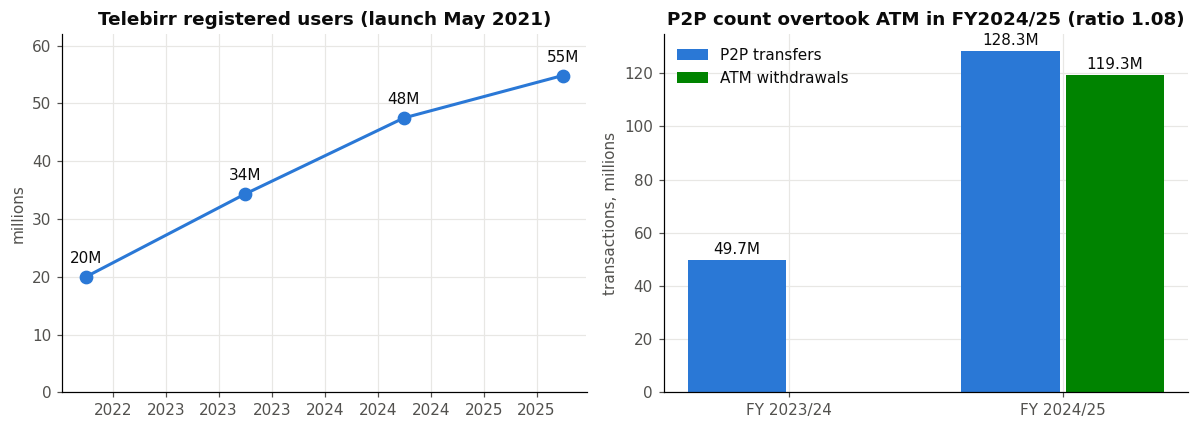

In [8]:
# Telebirr adoption ramp + P2P/ATM crossover
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(telebirr.observation_date, telebirr.value_numeric / 1e6, color=C1, lw=2, marker="o", ms=8)
for _, r in telebirr.iterrows():
    ax.annotate(f"{r.value_numeric/1e6:.0f}M", (r.observation_date, r.value_numeric/1e6),
                textcoords="offset points", xytext=(0, 9), ha="center", color=INK)
ax.set_title("Telebirr registered users (launch May 2021)")
ax.set_ylabel("millions"); ax.set_ylim(0, 62)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
p2p = obs[obs.indicator_code == "USG_P2P_COUNT"].sort_values("observation_date")
atm = obs[obs.indicator_code == "USG_ATM_COUNT"].sort_values("observation_date")
x = ["FY 2023/24", "FY 2024/25"]
w = 0.36
ax.bar([i - w/2 - 0.01 for i in range(2)], [p2p.value_numeric.iloc[0]/1e6, p2p.value_numeric.iloc[1]/1e6],
       width=w, color=C1, label="P2P transfers")
ax.bar([1 + w/2 + 0.01], [atm.value_numeric.iloc[0]/1e6], width=w, color=C2, label="ATM withdrawals")
ax.set_xticks([0, 1]); ax.set_xticklabels(x)
ax.annotate("49.7M", (0 - w/2 - 0.01, 49.7), textcoords="offset points", xytext=(0, 4), ha="center", color=INK)
ax.annotate("128.3M", (1 - w/2 - 0.01, 128.3), textcoords="offset points", xytext=(0, 4), ha="center", color=INK)
ax.annotate("119.3M", (1 + w/2 + 0.01, 119.3), textcoords="offset points", xytext=(0, 4), ha="center", color=INK)
ax.set_title("P2P count overtook ATM in FY2024/25 (ratio 1.08)")
ax.set_ylabel("transactions, millions"); ax.legend(frameon=False)
fig.tight_layout()
save(fig, "telebirr_p2p_atm.png"); plt.show()

**Registered vs active:** EthSwitch data confirms the crossover milestone — interoperable P2P
(128.3M transactions) exceeded ATM withdrawals (119.3M) in FY2024/25, having been less than half
ATM volume a year earlier (49.7M). But per Sheet D nuances, P2P rails in Ethiopia carry commerce,
not just transfers, so "P2P > ATM" signals merchant-type usage migrating to digital even while
formal merchant-payment metrics stay low.

## 4. Infrastructure and enablers

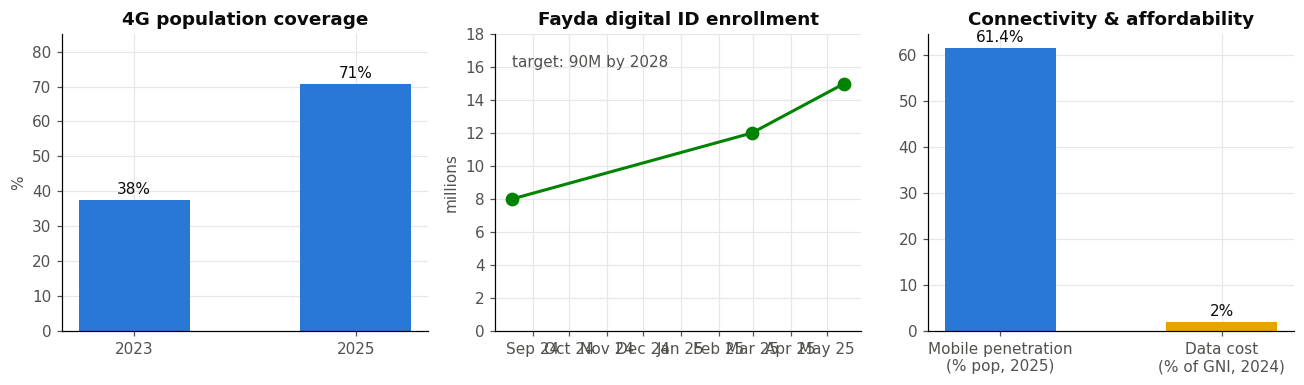

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
g4 = obs[obs.indicator_code == "ACC_4G_COV"].sort_values("year")
axes[0].bar(g4.year.astype(str), g4.value_numeric, color=C1, width=0.5)
for i, v in enumerate(g4.value_numeric):
    axes[0].annotate(f"{v:.0f}%", (i, v), textcoords="offset points", xytext=(0, 4),
                     ha="center", color=INK)
axes[0].set_title("4G population coverage"); axes[0].set_ylabel("%"); axes[0].set_ylim(0, 85)

fay = obs[obs.indicator_code == "ACC_FAYDA"].sort_values("observation_date")
axes[1].plot(fay.observation_date, fay.value_numeric / 1e6, color=C2, lw=2, marker="o", ms=8)
axes[1].set_title("Fayda digital ID enrollment")
axes[1].set_ylabel("millions"); axes[1].set_ylim(0, 18)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
axes[1].annotate("target: 90M by 2028", (fay.observation_date.iloc[0], 16), color=INK2)

mob = obs[obs.indicator_code.isin(["ACC_MOBILE_PEN", "AFF_DATA_INCOME"])]
axes[2].bar(["Mobile penetration\n(% pop, 2025)", "Data cost\n(% of GNI, 2024)"],
            mob.value_numeric.tolist(), color=[C1, C4], width=0.5)
for i, v in enumerate(mob.value_numeric):
    axes[2].annotate(f"{v:g}%", (i, v), textcoords="offset points", xytext=(0, 4),
                     ha="center", color=INK)
axes[2].set_title("Connectivity & affordability")
fig.tight_layout()
save(fig, "infrastructure.png"); plt.show()

**Leading-indicator logic:** 4G coverage nearly doubled (37.5%→70.8%, 2023–2025) and Fayda
enrollment is compounding — both are *enablers* that precede inclusion outcomes with a lag
(the impact links estimate 12–24 months). Mobile penetration at 61.4% remains the binding ceiling:
you cannot digitally include an adult who has no phone, and the mobile gender gap is 24%.

## 5. Event timeline and overlays

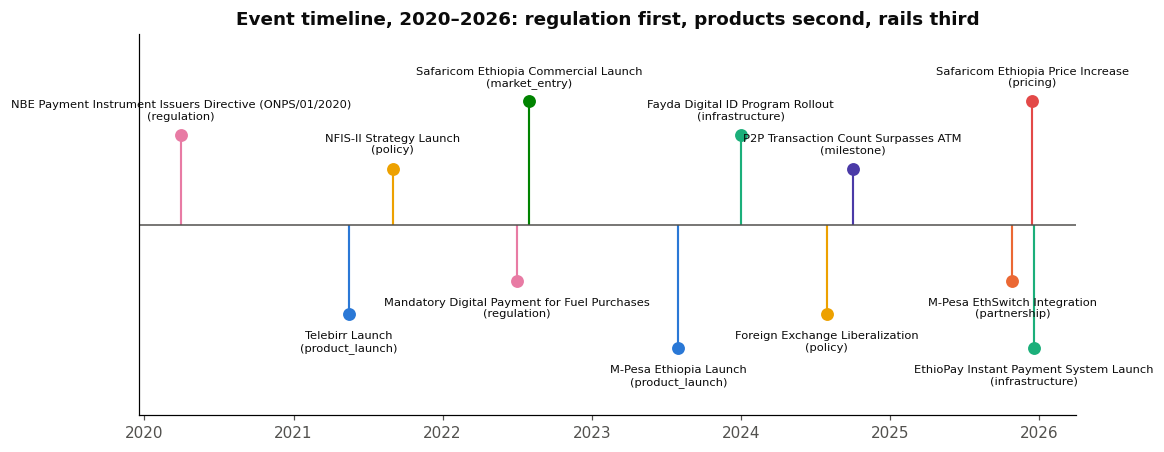

In [10]:
ev = events.sort_values("observation_date").reset_index(drop=True)
CAT_COLORS = {"product_launch": C1, "market_entry": C2, "regulation": C3, "policy": C4,
              "infrastructure": "#1baf7a", "partnership": "#eb6834", "milestone": "#4a3aa7",
              "pricing": "#e34948", "economic": INK2}

fig, ax = plt.subplots(figsize=(11, 4.5))
levels = [1.6, -1.6, 1.0, -1.0, 2.2, -2.2] * 3
for i, (_, r) in enumerate(ev.iterrows()):
    lv = levels[i]
    c = CAT_COLORS.get(r.category, INK2)
    ax.vlines(r.observation_date, 0, lv, color=c, lw=1.4)
    ax.scatter(r.observation_date, lv, color=c, s=55, zorder=3)
    ax.annotate(f"{r['indicator']}\n({r.category})", (r.observation_date, lv),
                textcoords="offset points", xytext=(0, 10 if lv > 0 else -24),
                ha="center", fontsize=7.5, color=INK)
ax.axhline(0, color=INK2, lw=1)
ax.set_ylim(-3.4, 3.4); ax.set_yticks([]); ax.grid(False)
ax.set_title("Event timeline, 2020–2026: regulation first, products second, rails third")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
save(fig, "event_timeline.png"); plt.show()

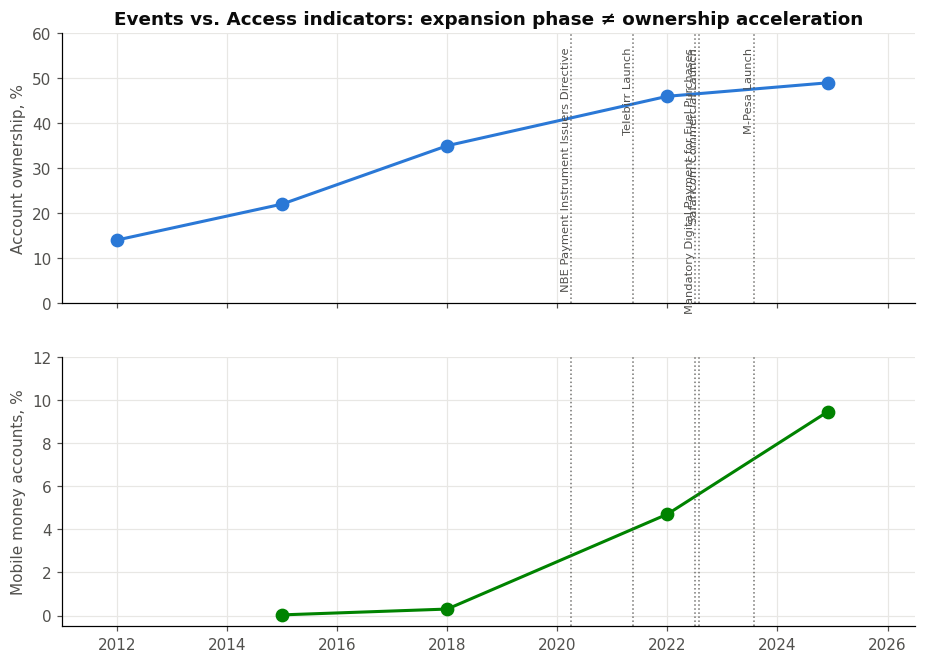

In [11]:
# Overlay events on the two Access indicator trends
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
key_events = ev[ev.record_id.isin(["EVT_0011", "EVT_0001", "EVT_0002", "EVT_0003", "EVT_0012"])]

ax = axes[0]
ax.plot(acc.observation_date, acc.value_numeric, color=C1, lw=2, marker="o", ms=8)
ax.set_ylabel("Account ownership, %"); ax.set_ylim(0, 60)
ax.set_title("Events vs. Access indicators: expansion phase ≠ ownership acceleration")

ax = axes[1]
ax.plot(mm.observation_date, mm.value_numeric, color=C2, lw=2, marker="o", ms=8)
ax.set_ylabel("Mobile money accounts, %"); ax.set_ylim(-0.5, 12)
ax.set_xlim(pd.Timestamp("2011-01-01"), pd.Timestamp("2026-06-30"))

for ax in axes:
    for _, r in key_events.iterrows():
        ax.axvline(r.observation_date, color=INK2, lw=1, ls=":", alpha=0.8)
for _, r in key_events.iterrows():
    axes[0].annotate(r["indicator"].replace(" Ethiopia", "").split(" (")[0],
                     (r.observation_date, 57), rotation=90, va="top", ha="right",
                     fontsize=7.5, color=INK2)
save(fig, "events_overlay.png"); plt.show()

**Visual reading of the overlays:**
- *Telebirr (May 2021)*: mobile money accounts jumped 0.3% → 4.7% → 9.45% across the surveys
  bracketing the launch — the clearest event effect in the data.
- *M-Pesa entry (Aug 2023)*: no separate survey point yet isolates it, but M-Pesa added ~10.8M
  registrations by Dec 2024, and MM accounts still only reached 9.45% — consistent with second
  providers adding registrations faster than *new* included adults.
- *Safaricom entry (Aug 2022)*: visible not in accounts but in enablers — 4G coverage roughly
  doubled after competitive network investment began (impact link IMP_0004).
- *Overall ownership stayed near-flat through all of it* — events moved usage and mobile money
  specifically, not headline inclusion.

## 6. Correlation analysis

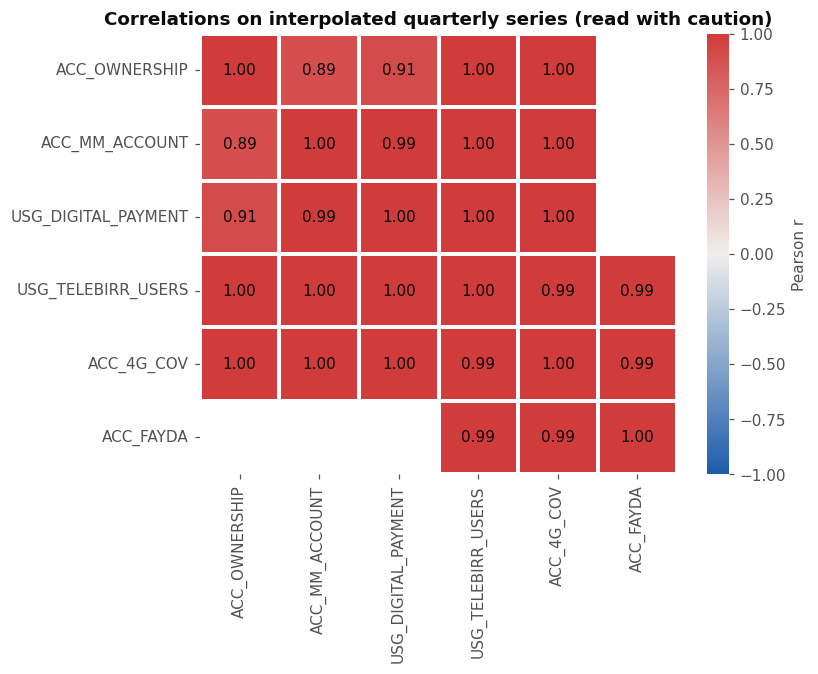

Overlapping quarters per pair:
                     ACC_OWNERSHIP  ACC_MM_ACCOUNT  USG_DIGITAL_PAYMENT  USG_TELEBIRR_USERS  ACC_4G_COV  ACC_FAYDA
ACC_OWNERSHIP                   53              41                   29                  11           7          2
ACC_MM_ACCOUNT                  41              41                   29                  11           7          2
USG_DIGITAL_PAYMENT             29              29                   29                  11           7          2
USG_TELEBIRR_USERS              11              11                   11                  13           9          4
ACC_4G_COV                       7               7                    7                   9           9          4
ACC_FAYDA                        2               2                    2                   4           4          4


In [12]:
# Interpolate sparse series onto a quarterly grid (2011–2025) — for association only
codes = ["ACC_OWNERSHIP", "ACC_MM_ACCOUNT", "USG_DIGITAL_PAYMENT",
         "USG_TELEBIRR_USERS", "ACC_4G_COV", "ACC_FAYDA"]
qidx = pd.period_range("2011Q1", "2025Q4", freq="Q")
frame = {}
for c in codes:
    d = obs[(obs.indicator_code == c) & (obs.gender == "all")]
    s = d.set_index(d.observation_date.dt.to_period("Q")).value_numeric.groupby(level=0).mean()
    frame[c] = s.reindex(qidx).interpolate(limit_area="inside")
quarterly = pd.DataFrame(frame, index=qidx)
corr = quarterly.corr(min_periods=4)

fig, ax = plt.subplots(figsize=(7, 5.2))
sns.heatmap(corr, ax=ax, cmap=DIVERGING, vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=1.5, linecolor="white", cbar_kws={"label": "Pearson r"},
            annot_kws={"color": INK})
ax.set_title("Correlations on interpolated quarterly series (read with caution)")
ax.grid(False)
save(fig, "correlation.png"); plt.show()
print("Overlapping quarters per pair:")
print(quarterly.notna().astype(int).T.dot(quarterly.notna().astype(int)))

In [13]:
# What do the impact links say? Tally links by pillar and by target indicator
links = impact.merge(events[["record_id", "indicator", "category"]]
                     .rename(columns={"record_id": "parent_id", "indicator": "event_name",
                                      "category": "event_category"}),
                     on="parent_id", how="left")
display(links.groupby("pillar").size().to_frame("n_links"))
display(links.groupby("related_indicator").size().sort_values(ascending=False).to_frame("n_links"))
display(links.groupby(["event_category", "pillar"]).size().unstack(fill_value=0))

,n_links
pillar,
ACCESS,8
AFFORDABILITY,3
GENDER,1
USAGE,11


,n_links
related_indicator,
ACC_MM_ACCOUNT,4
USG_DIGITAL_PAYMENT,4
AFF_DATA_INCOME,3
ACC_OWNERSHIP,3
USG_P2P_COUNT,3
USG_TELEBIRR_USERS,2
ACC_4G_COV,1
GEN_GAP_ACC,1
USG_MPESA_USERS,1


pillar,ACCESS,AFFORDABILITY,GENDER,USAGE
event_category,,,,
infrastructure,2,0,1,2
market_entry,1,1,0,0
partnership,0,0,0,2
policy,1,1,0,0
pricing,0,1,0,0
product_launch,3,0,0,5
regulation,1,0,0,2


**Caution on the correlation matrix:** every series trends upward over a short window, so
pairwise correlations are ~0.9+ by construction; with ≤5 real data points per series these are
*co-trends, not causal evidence*. The value of the matrix is directional: enablers (4G, Fayda,
Telebirr users) co-move most tightly with `USG_DIGITAL_PAYMENT` and `ACC_MM_ACCOUNT`, and far less
tightly with `ACC_OWNERSHIP` — the same decoupling seen in the trend charts. Causal claims are
deferred to the impact-link model (Task 3), which uses documented comparable-country evidence.

**From the impact links:** USAGE receives the most links (mostly `direct`, short 3–6 month lags);
ACCESS links are mostly `enabling` with 12–24 month lags — consistent with usage responding fast
to events while ownership responds slowly through enablers.

## 7. Key insights

**1. Access growth has decoupled from digital expansion.** Ownership grew +1.0pp/yr in 2021–24
vs +4.3pp/yr in 2014–17, while 65M+ wallets were registered and P2P overtook ATM. Evidence:
access trajectory & growth chart; registered-vs-survey chart (~9x gap).

**2. The registration–inclusion gap is the defining measurement problem.** ~66M registered
wallets vs ~7M survey-reported mobile money owners (9.45% of adults). Duplicates, inactivity
(M-Pesa 90-day active rate: 66%), and bank-account overlap (mobile-money-only adults: ~0.5%)
explain most of it. Operator counts cannot be used as inclusion measures — only as leading
indicators.

**3. Usage is the momentum story, not access.** Digital payment usage roughly tripled 2017–2024
(~12% → ~35%) and its growth *accelerated* post-2021, while ownership stagnated. The two Findex
pillars now require separate models with different drivers — justifying the project's two-target
design.

**4. Events move usage quickly and access slowly, through enablers.** The Telebirr launch is
bracketed by a 0.3%→9.45% mobile money jump; the 2022 fuel mandate coincided with Telebirr's
fastest user growth (20M→34.3M in a year); meanwhile regulation (2020 PSP directive) preceded
the whole market. Impact links encode this: USAGE links have 3–6 month lags, ACCESS links 12–24.

**5. The gender gap is structural and nearly static: 20pp → 18pp (2021→2024).** Female ownership
(~40%) trails male (~58%); the mobile phone gender gap (24%) and female share of mobile money
accounts (14%) suggest device access and norms, not product availability, are binding.

**6. The NFIS-II 70%-by-2025 target is out of reach.** At the observed +1pp/yr, 2025 lands near
50%, 20pp short. Forecast scenarios (Task 4) should treat 70% as aspirational context, and the
dashboard's 60% progress bar as the realistic frontier target.

## Data quality assessment

| Limitation | Impact on analysis |
|---|---|
| Only 5–6 Findex survey points per target indicator (3-yearly) | Trend fits have very wide uncertainty; no within-cycle dynamics observable |
| Operator counts ≠ inclusion (registration inflation) | Supply-side data usable only as leading indicators, never as levels |
| Infrastructure series start ~2022–2023 | Pre/post comparisons for early events rely on comparable-country literature |
| Gender/urban-rural disaggregation thin (2 years, partly derived) | Gap analysis is directional; 2024 male/female values flagged `estimated` |
| Several enrichment values are press-reported (medium confidence) | Documented in enrichment log; sensitivity checks needed in Task 3/4 |
| Interpolated annual series used for correlations | Correlations are co-trends; not evidence of causation |